In [1]:
import pandas as pd
import matplotlib.pyplot as plt

LOAD FILES

In [3]:
df_history = pd.read_csv(
    "comparison/results/history_only_xgb_results.csv"
)

df_physics = pd.read_csv(
    "comparison/results/physics_only_xgb_results.csv"
)

df_history_physics = pd.read_csv(
    "comparison/results/history_physics_xgb_results.csv"
)

df_hybrid = pd.read_csv(
    "comparison/results/Hybrid_xgb_results.csv"
)

rename models

In [4]:
df_history["Model"] = "History Only"

df_physics["Model"] = "Physics Only"

df_history_physics["Model"] = "History + Physics"

df_hybrid["Model"] = "Hybrid Delta"

contact 


In [5]:
df_cases = pd.concat([

    df_history,
    df_physics,
    df_history_physics,
    df_hybrid

], ignore_index=True)

In [6]:
df_cases_global = (

    df_cases
    .groupby("Model")["R2"]
    .mean()
    .reset_index()

)

df_cases_global = df_cases_global.sort_values(
    "R2",
    ascending=False
)

print(df_cases_global)

               Model        R2
2       Hybrid Delta  0.941708
0  History + Physics  0.939188
1       History Only  0.935940
3       Physics Only  0.562303


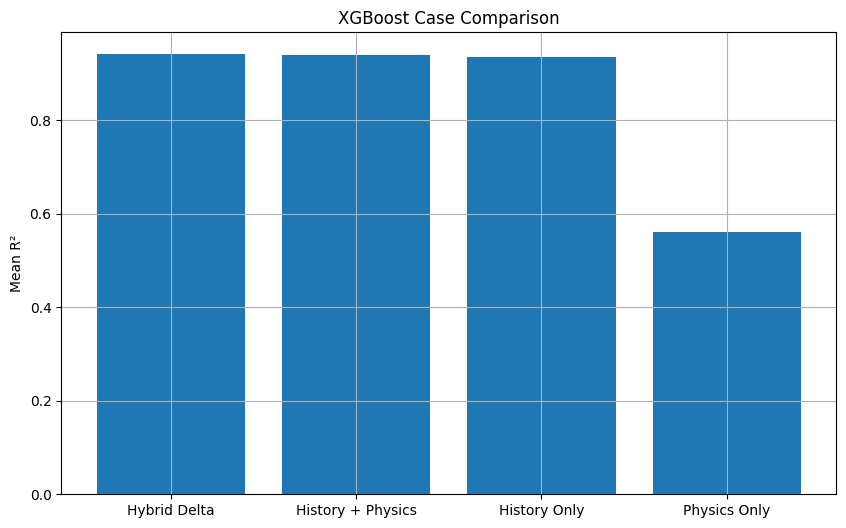

In [7]:
plt.figure(figsize=(10,6))

plt.bar(
    df_cases_global["Model"],
    df_cases_global["R2"]
)

plt.title("XGBoost Case Comparison")
plt.ylabel("Mean R²")

plt.grid()

plt.show()

comparison2

LOAD FILES

In [8]:
df_hybrid_models = pd.read_csv(
    "comparison/results/hybrid_global_comparison.csv"
)

df_lstm = pd.read_csv(
    "comparison/results/lstm_results.csv"
)

In [9]:
df_models = pd.concat([

    df_hybrid_models,
    df_lstm

], ignore_index=True)

In [10]:
df_models_global = (

    df_models
    .groupby("Model")["R2"]
    .mean()
    .reset_index()

)

df_models_global = df_models_global.sort_values(
    "R2",
    ascending=False
)

print(df_models_global)

   Model        R2
3   LSTM  0.944426
6    XGB  0.941708
0    ANN  0.941103
2     LR  0.935222
5     RF  0.931956
1     DT  0.927843
4  NAIVE  0.917317


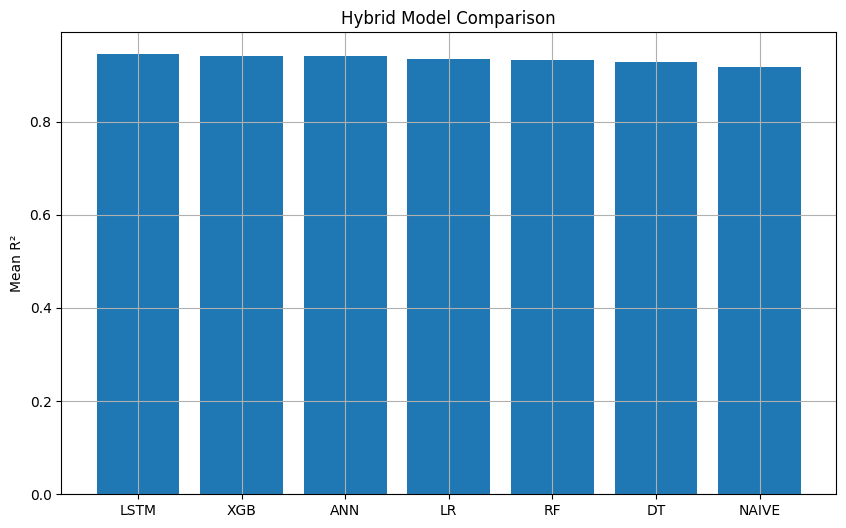

In [11]:
plt.figure(figsize=(10,6))

plt.bar(
    df_models_global["Model"],
    df_models_global["R2"]
)

plt.title("Hybrid Model Comparison")
plt.ylabel("Mean R²")

plt.grid()

plt.show()

In [12]:
pivot = df_models.pivot(
    index="Model",
    columns="Target",
    values="R2"
)

print(pivot)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.969134  0.907020  0.947154
DT      0.960734  0.881155  0.941641
LR      0.959881  0.904911  0.940873
LSTM    0.938920  0.951221  0.943137
NAIVE   0.949774  0.879593  0.922582
RF      0.965327  0.883754  0.946786
XGB     0.967668  0.905043  0.952412
